# Ablation D - Last3 Upgraded

Last3Layers baseline with GELU + lr=3e-4 + best-by-val_acc

In [1]:
import torch, subprocess

print(f'cuda available: {torch.cuda.is_available()}')
print(f'visible gpus: {torch.cuda.device_count()}')
print(f'dataparallel suggested: {torch.cuda.device_count() > 1}')
if torch.cuda.is_available():
    print('gpu names:', [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
try:
    q = ['nvidia-smi','--query-gpu=index,memory.used,memory.total,utilization.gpu','--format=csv,noheader,nounits']
    out = subprocess.check_output(q, text=True).strip()
    print('per-gpu (idx, mem_usedMB, mem_totalMB, util%):')
    print(out if out else '(empty)')
except Exception as e:
    print(f'nvidia-smi unavailable: {e}')


cuda available: True
visible gpus: 2
dataparallel suggested: True
gpu names: ['NVIDIA RTX A5000', 'NVIDIA RTX A5000']
per-gpu (idx, mem_usedMB, mem_totalMB, util%):
0, 2263, 24564, 0
1, 1291, 24564, 0


In [2]:
import os
import sys
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import timm

BASE_PATH = Path('/gpfs/gibbs/project/papademetris/jg3279')
DATA_PATH = BASE_PATH / 'data' / 'USenhance_2023_split'
OUTPUT_PATH = BASE_PATH / 'USFM' / 'week9' / 'ablation_D_last3_upgraded'
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Device: {device}')
if torch.cuda.is_available():
    print(f'✓ GPUs: {torch.cuda.device_count()}')

print('torch version:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('cuda device count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('current device:', torch.cuda.current_device())
    print('gpu name:', torch.cuda.get_device_name(torch.cuda.current_device()))
    print('cuda version (torch):', torch.version.cuda)

CONFIG = {
    'batch_size': 64,
    'num_epochs': 50,
    'learning_rate': 3e-4,
    'weight_decay': 1e-4,
    'num_workers': 8,
    'seed': 42,
    'deterministic': False,
    'organ_classes': ['breast', 'carotid', 'kidney', 'liver', 'thyroid']
}

random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])
if CONFIG['deterministic']:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print('\n📋 Config:')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')


✓ Device: cuda
✓ GPUs: 2
torch version: 2.4.1+cu118
cuda available: True
cuda device count: 2
current device: 0
gpu name: NVIDIA RTX A5000
cuda version (torch): 11.8

📋 Config:
  batch_size: 64
  num_epochs: 50
  learning_rate: 0.0003
  weight_decay: 0.0001
  num_workers: 8
  seed: 42
  deterministic: False
  organ_classes: ['breast', 'carotid', 'kidney', 'liver', 'thyroid']


In [3]:
class OrganDataset(Dataset):
    def __init__(self, data_path, split='train', transform=None):
        self.split = split
        self.transform = transform
        self.organ_classes = CONFIG['organ_classes']
        self.organ_to_idx = {organ: idx for idx, organ in enumerate(self.organ_classes)}
        self.data_path = Path(data_path) / split
        self.samples = []
        self._load_samples()

    def _load_samples(self):
        for organ in self.organ_classes:
            organ_path = self.data_path / organ
            if organ_path.exists():
                for quality_dir in organ_path.glob('*quality'):
                    for img_file in quality_dir.glob('*.png'):
                        self.samples.append({
                            'path': img_file,
                            'organ': organ,
                            'organ_idx': self.organ_to_idx[organ],
                            'quality': quality_dir.name
                        })
        print(f'✓ {self.split.upper()}: {len(self.samples)} images')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return {
            'image': img,
            'organ_label': sample['organ_idx'],
            'organ_name': sample['organ'],
            'quality': sample['quality'],
            'path': str(sample['path'])
        }

print('✓ Dataset class defined')


✓ Dataset class defined


In [4]:
class OrganClassifierFrozen(nn.Module):
    """只微调最后3层的classifier"""
    def __init__(self, backbone, num_classes=5):
        super().__init__()
        self.backbone = backbone
        self.num_classes = num_classes

        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224).to(next(backbone.parameters()).device)
            features = backbone.forward_features(dummy_input)
            embedding_dim = features.shape[-1]

        self.embedding_dim = embedding_dim
        print(f'✓ Embedding dim: {embedding_dim}')

        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 512),
            nn.GELU(),           # ablation D: match ExtraBlock experiments
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

        self._freeze_all_but_last_3_layers()

    def _freeze_all_but_last_3_layers(self):
        """冻结backbone的所有层，只解冻最后3个transformer块"""
        for param in self.backbone.parameters():
            param.requires_grad = False

        if hasattr(self.backbone, 'blocks'):
            for block in self.backbone.blocks[-3:]:
                for param in block.parameters():
                    param.requires_grad = True

        if hasattr(self.backbone, 'norm'):
            for param in self.backbone.norm.parameters():
                param.requires_grad = True

        print('✓ Frozen all layers except last 3 blocks')

    def _get_cls_token(self, features):
        if features.dim() == 3:
            return features[:, 0, :]
        return features

    def forward(self, x, extract_features_only=False):
        features = self.backbone.forward_features(x)
        cls_token = self._get_cls_token(features)

        if extract_features_only:
            return cls_token

        logits = self.classifier(cls_token)
        return logits

print('✓ Model class defined')


✓ Model class defined


In [5]:
print('Loading USFM...')
backbone = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=1000)

usfm_weight_path = BASE_PATH / 'USFM' / 'assets' / 'FMweight' / 'USFM_latest.pth'
if usfm_weight_path.exists():
    try:
        checkpoint = torch.load(usfm_weight_path, map_location='cpu', weights_only=True)
    except TypeError:
        checkpoint = torch.load(usfm_weight_path, map_location='cpu')

    state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

    try:
        backbone.load_state_dict(state_dict, strict=True)
    except RuntimeError as e:
        print(f'Warning: strict load failed, fallback to strict=False. {e}')
        backbone.load_state_dict(state_dict, strict=False)

    print('✓ USFM weights loaded')
else:
    print(f'Warning: weight file not found: {usfm_weight_path}')


Loading USFM...
	Missing key(s) in state_dict: "pos_embed", "blocks.0.attn.qkv.bias", "blocks.1.attn.qkv.bias", "blocks.2.attn.qkv.bias", "blocks.3.attn.qkv.bias", "blocks.4.attn.qkv.bias", "blocks.5.attn.qkv.bias", "blocks.6.attn.qkv.bias", "blocks.7.attn.qkv.bias", "blocks.8.attn.qkv.bias", "blocks.9.attn.qkv.bias", "blocks.10.attn.qkv.bias", "blocks.11.attn.qkv.bias", "head.weight", "head.bias". 
	Unexpected key(s) in state_dict: "mask_token", "rel_pos_bias.relative_position_bias_table", "rel_pos_bias.relative_position_index", "blocks.0.gamma_1", "blocks.0.gamma_2", "blocks.0.attn.q_bias", "blocks.0.attn.v_bias", "blocks.1.gamma_1", "blocks.1.gamma_2", "blocks.1.attn.q_bias", "blocks.1.attn.v_bias", "blocks.2.gamma_1", "blocks.2.gamma_2", "blocks.2.attn.q_bias", "blocks.2.attn.v_bias", "blocks.3.gamma_1", "blocks.3.gamma_2", "blocks.3.attn.q_bias", "blocks.3.attn.v_bias", "blocks.4.gamma_1", "blocks.4.gamma_2", "blocks.4.attn.q_bias", "blocks.4.attn.v_bias", "blocks.5.gamma_1", "blo

In [6]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop((224, 224), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = OrganDataset(DATA_PATH, split='train', transform=train_transform)
val_dataset = OrganDataset(DATA_PATH, split='val', transform=val_transform)
test_dataset = OrganDataset(DATA_PATH, split='test', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=CONFIG['num_workers'], pin_memory=True)
train_extract_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)

print('✓ Data loaded')


✓ TRAIN: 1480 images
✓ VAL: 310 images
✓ TEST: 310 images
✓ Data loaded


/home/jg3279/.conda/envs/USFM/lib/python3.9/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [7]:
model = OrganClassifierFrozen(backbone=backbone, num_classes=5)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

print('model param device:', next(model.parameters()).device)

# 统计参数
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✓ Total params: {total_params:,}')
print(f'✓ Trainable params: {trainable_params:,}')
print(f'✓ Frozen params: {total_params - trainable_params:,}')
print(f'  Ratio: {trainable_params/total_params*100:.2f}% trainable')

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['num_epochs'], eta_min=1e-6)

print('✓ Optimizer ready')


✓ Embedding dim: 768
✓ Frozen all layers except last 3 blocks
model param device: cuda:0
✓ Total params: 86,963,949
✓ Trainable params: 21,661,445
✓ Frozen params: 65,302,504
  Ratio: 24.91% trainable
✓ Optimizer ready


In [8]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(dataloader, desc='Training', leave=False):
        images = batch['image'].to(device)
        labels = batch['organ_label'].to(device)

        if total == 0:
            print('images device:', images.device)
            print('labels device:', labels.device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    if len(dataloader) == 0 or total == 0:
        return float('nan'), 0.0
    return total_loss / len(dataloader), correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Validating', leave=False):
            images = batch['image'].to(device)
            labels = batch['organ_label'].to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    if len(dataloader) == 0 or total == 0:
        return float('nan'), 0.0
    return total_loss / len(dataloader), correct / total

print('✓ Training functions defined')


✓ Training functions defined


In [9]:
print('\nStarting training...')
train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0
best_model_path = OUTPUT_PATH / 'best_model.pth'
patience = 15
patience_counter = 0

for epoch in range(CONFIG['num_epochs']):
    print(f'Epoch [{epoch+1}/{CONFIG["num_epochs"]}]', end=' | ')

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f'Train: {train_loss:.4f}/{train_acc:.4f} | Val: {val_loss:.4f}/{val_acc:.4f}', end='')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'val_acc': val_acc}, best_model_path)
        print(' ✓')
    else:
        patience_counter += 1
        print()
        if patience_counter >= patience:
            print(f'\nEarly stopping at epoch {epoch}')
            break

print(f'\nTraining done. Best Val Acc: {best_val_acc:.4f}')



Starting training...
Epoch [1/50] | 

Training:   0%|          | 0/24 [00:00<?, ?it/s]

images device: cuda:0
labels device: cuda:0


Train: 1.4273/0.3426 | Val: 1.1281/0.4839 ✓
Epoch [2/50] | 

Training:   0%|          | 0/24 [00:00<?, ?it/s]

...

images device: cuda:0
labels device: cuda:0


Train: 0.2206/0.8926 | Val: 0.2148/0.9000
Epoch [50/50] | 

Training:   0%|          | 0/24 [00:00<?, ?it/s]

images device: cuda:0
labels device: cuda:0


Train: 0.2241/0.9020 | Val: 0.2146/0.9032 ✓

Training done. Best Val Acc: 0.9032


✓ Test Loss: 0.3557
✓ Test Accuracy: 0.8548


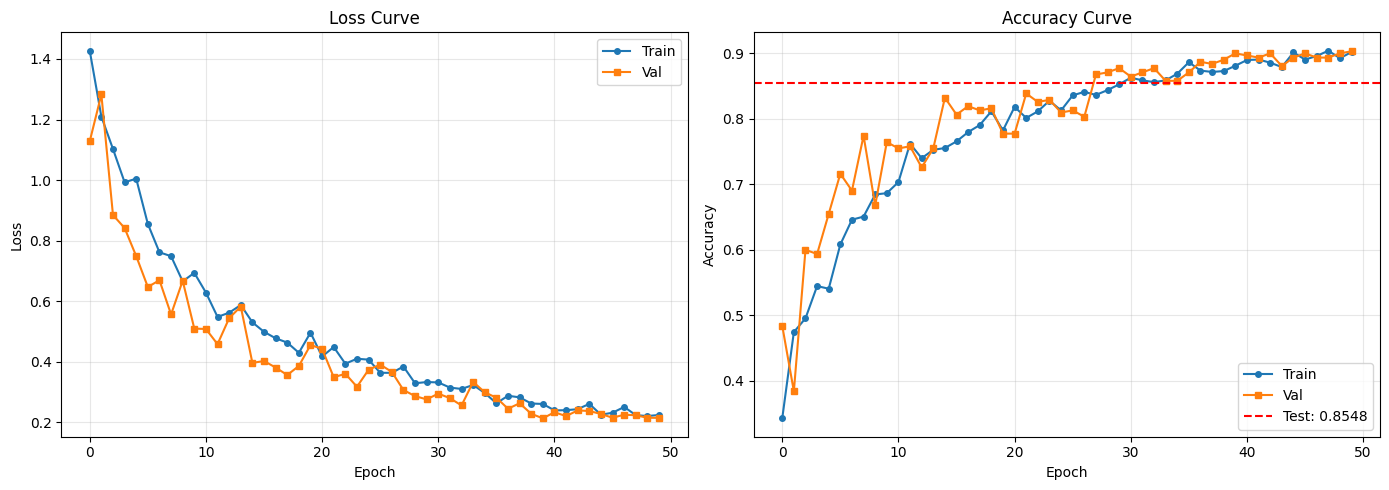

✓ Saved curves


In [10]:
if best_model_path.exists():
    try:
        checkpoint = torch.load(best_model_path, map_location=device, weights_only=True)
    except TypeError:
        checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    raise FileNotFoundError(f'Best model not found: {best_model_path}')

test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f'✓ Test Loss: {test_loss:.4f}')
print(f'✓ Test Accuracy: {test_acc:.4f}')

# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label='Train', marker='o', markersize=4)
axes[0].plot(val_losses, label='Val', marker='s', markersize=4)
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Loss Curve')

axes[1].plot(train_accs, label='Train', marker='o', markersize=4)
axes[1].plot(val_accs, label='Val', marker='s', markersize=4)
axes[1].axhline(y=test_acc, color='r', linestyle='--', label=f'Test: {test_acc:.4f}')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Accuracy Curve')

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved curves')


In [11]:
# 提取embeddings
def extract_embeddings(model, dataloader, device):
    model.eval()
    embeddings_list = []
    organs_list = []
    quality_list = []
    path_list = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Extracting', leave=False):
            images = batch['image'].to(device)
            embeddings = model(images, extract_features_only=True)
            embeddings_list.append(embeddings.cpu().numpy())
            organs_list.extend(batch['organ_name'])
            quality_list.extend(batch['quality'])
            path_list.extend(batch['path'])

    return np.vstack(embeddings_list), np.array(organs_list), np.array(quality_list), np.array(path_list)

all_embeddings_list = []
all_organs_list = []
all_quality_list = []
all_paths_list = []
splits_list = []

for split_name, loader in [('train', train_extract_loader), ('val', val_loader), ('test', test_loader)]:
    embeddings, organs, quality, paths = extract_embeddings(model, loader, device)
    all_embeddings_list.append(embeddings)
    all_organs_list.extend(organs)
    all_quality_list.extend(quality)
    all_paths_list.extend(paths)
    splits_list.extend([split_name] * len(organs))
    print(f'✓ {split_name}: {embeddings.shape}')

embeddings_last3 = np.vstack(all_embeddings_list)
organs_last3 = np.array(all_organs_list)
quality_last3 = np.array(all_quality_list)
paths_last3 = np.array(all_paths_list)
splits_last3 = np.array(splits_list)

np.save(OUTPUT_PATH / 'embeddings.npy', embeddings_last3)
np.save(OUTPUT_PATH / 'organs.npy', organs_last3)
np.save(OUTPUT_PATH / 'quality.npy', quality_last3)
np.save(OUTPUT_PATH / 'paths.npy', paths_last3)
np.save(OUTPUT_PATH / 'splits.npy', splits_last3)

print(f'\n✅ Done! Total: {embeddings_last3.shape}')
print(f'📊 Results Summary:')
print(f'  Best Val Acc: {best_val_acc:.4f}')
print(f'  Test Acc: {test_acc:.4f}')
print(f'  Total Epochs: {len(train_losses)}')


✓ train: (1480, 768)


✓ val: (310, 768)


✓ test: (310, 768)

✅ Done! Total: (2100, 768)
📊 Results Summary:
  Best Val Acc: 0.9032
  Test Acc: 0.8548
  Total Epochs: 50
